In [1]:
# [CELL 1] Cài đặt và khai báo thư viện
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from underthesea import sent_tokenize, word_tokenize

Số câu tách được: 5
Câu 1 sau tiền xử lý: ['nhanh', 'số']
Ma trận tương đồng Cosine:
[[0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.29]
 [0.   0.   0.   0.29 0.  ]
 [0.   0.   0.29 0.   0.  ]
 [0.   0.29 0.   0.   0.  ]]


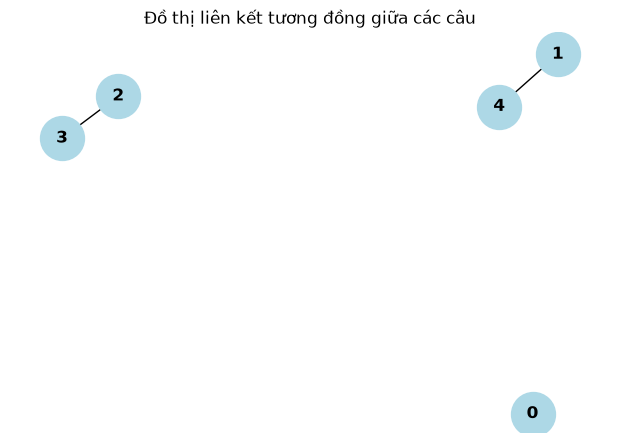


--- BẢNG XẾP HẠNG PAGERANK ---
Hạng 1 (PR: 0.2410): Câu 5
Hạng 2 (PR: 0.2410): Câu 4
Hạng 3 (PR: 0.2410): Câu 3
Hạng 4 (PR: 0.2410): Câu 2
Hạng 5 (PR: 0.0361): Câu 1


In [2]:
# [CELL 2] Khai báo văn bản thử nghiệm và Từ dừng (Stopwords)
raw_text = """
Trí tuệ nhân tạo đang phát triển rất nhanh trong kỷ nguyên số.
Các mô hình xử lý ngôn ngữ tự nhiên giúp máy tính hiểu được tiếng Việt.
Phương pháp đồ thị cho phép rút trích các câu quan trọng nhất trong văn bản.
Thuật toán PageRank được ứng dụng hiệu quả để tính toán độ quan trọng của từng câu.
Hệ thống tóm tắt tự động giúp tiết kiệm thời gian đọc hiểu cho người dùng.
"""

STOP_WORDS = set(["đang", "rất", "trong", "các", "được", "cho", "của", "để", "giúp"])

# [CELL 3] Tiền xử lý: Tách câu, tách từ, loại bỏ từ dừng
sentences = sent_tokenize(raw_text)
processed_sentences = []

for sent in sentences:
    words = word_tokenize(sent.lower())
    words_clean = [w for w in words if w not in STOP_WORDS and re.match(r'^\w+$', w)]
    processed_sentences.append(words_clean)

print("Số câu tách được:", len(sentences))
print("Câu 1 sau tiền xử lý:", processed_sentences[0])

# [CELL 4] Định nghĩa các hàm tính độ tương đồng
def jaccard_similarity(w1, w2):
    s1, s2 = set(w1), set(w2)
    return len(s1.intersection(s2)) / len(s1.union(s2)) if s1.union(s2) else 0.0

def cosine_similarity(w1, w2):
    all_words = list(set(w1).union(set(w2)))
    if not all_words: return 0.0
    v1 = [1 if w in w1 else 0 for w in all_words]
    v2 = [1 if w in w2 else 0 for w in all_words]
    dot = sum(a * b for a, b in zip(v1, v2))
    norm = (sum(a*a for a in v1)**0.5) * (sum(b*b for b in v2)**0.5)
    return dot / norm if norm else 0.0

# [CELL 5] Xây dựng ma trận tương đồng (Similarity Matrix)
n = len(processed_sentences)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            sim_matrix[i][j] = cosine_similarity(processed_sentences[i], processed_sentences[j])

print("Ma trận tương đồng Cosine:")
print(np.round(sim_matrix, 2))

# [CELL 6] Tính điểm PageRank và Trích xuất tóm tắt
nx_graph = nx.from_numpy_array(sim_matrix)
scores = nx.pagerank(nx_graph, alpha=0.85)

# Trực quan hóa Đồ thị tương đồng câu
plt.figure(figsize=(6, 4))
nx.draw(nx_graph, with_labels=True, node_color='lightblue', node_size=1000, font_weight='bold')
plt.title("Đồ thị liên kết tương đồng giữa các câu")
plt.show()

# In kết quả xếp hạng
ranked = sorted(((scores[i], i, sentences[i]) for i in range(n)), reverse=True)
print("\n--- BẢNG XẾP HẠNG PAGERANK ---")
for rank, (score, idx, sent) in enumerate(ranked):
    print(f"Hạng {rank+1} (PR: {score:.4f}): Câu {idx+1}")